In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler

In [2]:
np.random.seed(42)
df = pd.DataFrame({'Person':[f"A{i}" for i in range(1,31)],
                   'Age':np.random.randint(20,60,30), 
                   'Salary':np.random.randint(20,90,30)})
X = df[['Age','Salary']].values

In [3]:
df

,Person,Age,Salary
0,A1,58,81
1,A2,48,81
2,A3,34,66
3,A4,27,81
4,A5,40,70
5,A6,58,74
6,A7,38,83
7,A8,42,22
8,A9,30,70
9,A10,30,26


In [4]:
# Normalize the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# Create linkage matrix
linked = linkage(X_scaled, method = 'ward')

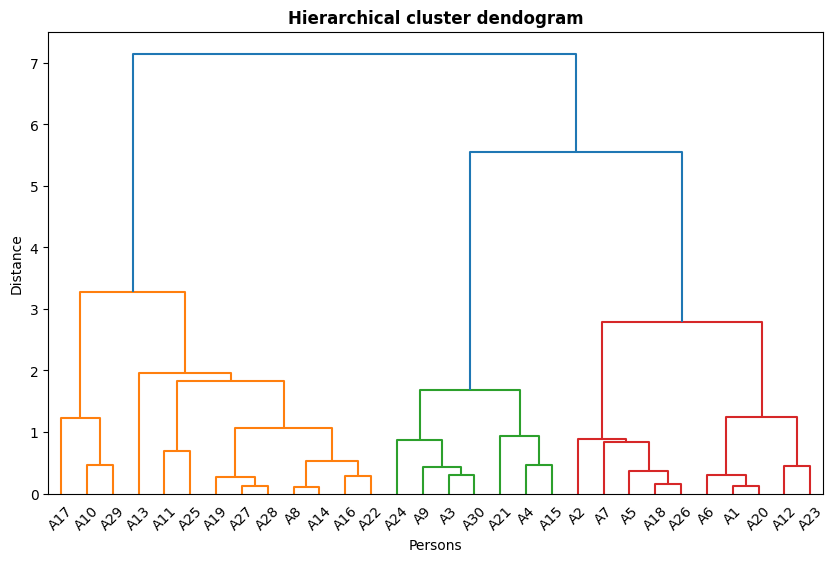

In [6]:
plt.figure(figsize=(10,6))
dendrogram(linked, labels=df['Person'].values)
plt.title('Hierarchical cluster dendogram',fontweight='bold')
plt.xlabel('Persons')
plt.ylabel('Distance')
plt.show()

In [7]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

scores = []

for k in range(2,11):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    scores.append((k, score))

for k, score in scores:
    print(f"Clusters : {k}, Silhouette Score : {score}")

Clusters : 2, Silhouette Score : 0.4001539619916242
Clusters : 3, Silhouette Score : 0.4431697605315711
Clusters : 4, Silhouette Score : 0.41671963352526614
Clusters : 5, Silhouette Score : 0.40122590308680134
Clusters : 6, Silhouette Score : 0.3937630240934166
Clusters : 7, Silhouette Score : 0.39088197525229457
Clusters : 8, Silhouette Score : 0.388746295705194
Clusters : 9, Silhouette Score : 0.4096258880384783
Clusters : 10, Silhouette Score : 0.3983770899257541


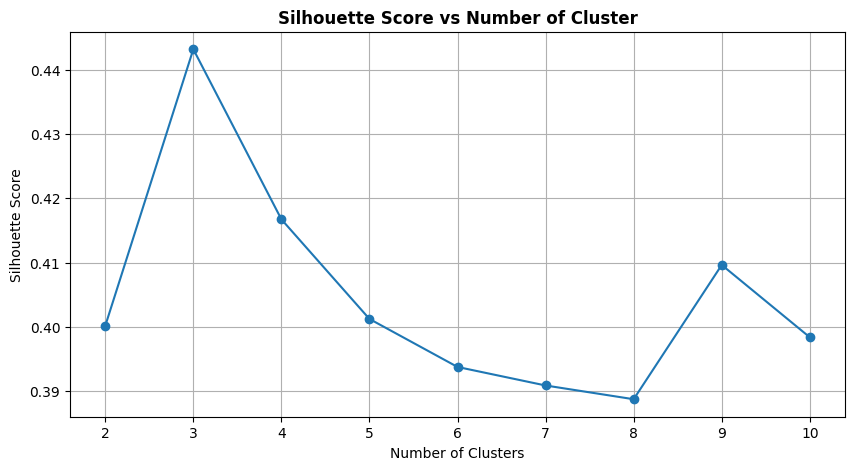

In [8]:
plt.figure(figsize=(10,5))
plt.plot([k for k, s in scores],[s for k, s in scores], marker='o')
plt.title('Silhouette Score vs Number of Cluster',fontweight='bold')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [9]:
best_k = max(scores,key = lambda x:x[1])[0]
print("Best number of Cluster : ",best_k)

Best number of Cluster :  3


In [10]:
final_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
df['Cluster'] = final_model.fit_predict(X_scaled)

In [11]:
print(df['Cluster'].value_counts())

Cluster
0    13
1    10
2     7
Name: count, dtype: int64


In [12]:
df

,Person,Age,Salary,Cluster
0,A1,58,81,1
1,A2,48,81,1
2,A3,34,66,2
3,A4,27,81,2
4,A5,40,70,1
5,A6,58,74,1
6,A7,38,83,1
7,A8,42,22,0
8,A9,30,70,2
9,A10,30,26,0


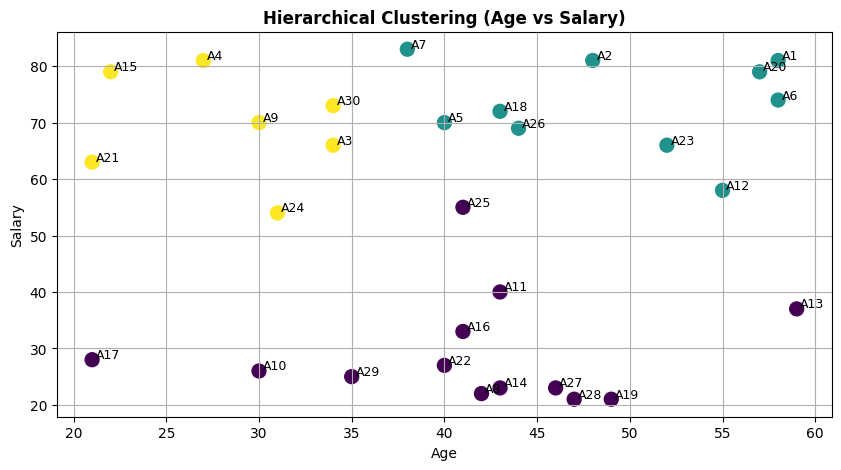

In [13]:
plt.figure(figsize=(10,5))
plt.scatter(df['Age'],df['Salary'], c=df['Cluster'], s= 100)
for i in range(len(df)):
    plt.text(df['Age'][i]+0.2, df['Salary'][i]+0.2, df['Person'][i], fontsize=9)
plt.title('Hierarchical Clustering (Age vs Salary)',fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.grid(True)
plt.show()